# Survival analysis with Coxph

`pymlt.Coxph` fits a proportional-hazards model in which the baseline
log-cumulative-hazard is modelled as a flexible, monotone Bernstein
polynomial and the link function is the minimum-extreme-value distribution.
With covariates entering linearly, this is equivalent to the classical
Cox proportional-hazards model, but the baseline distribution is estimated
smoothly rather than left fully non-parametric.

This vignette reproduces the Cox-PH illustration from Hothorn (2020) on
synthetic right-censored data and compares the estimated survival curve
to the Kaplan-Meier estimate from [lifelines](https://lifelines.readthedocs.io/).

> *lifelines is an optional dependency:* install with
> `pip install "pymlt[examples]"`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

import pymlt

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

## Data-generating process

250 event times from $T\sim\text{Exp}(\text{scale}=2)$, observed under
independent uniform right-censoring. The censoring window is tuned to a
~30 % censoring rate, a realistic setting for observational follow-up
studies.

pymlt expects a `CensoredData` container with the convention
`censored=True` when the event is *not* observed.

In [2]:
n = 250
t_event = rng.exponential(scale=2.0, size=n)
c = rng.uniform(0.8, 5.0, size=n)
y_obs = np.minimum(t_event, c)
event = t_event <= c         # True -> exact observation
censored = ~event            # pymlt: True -> right-censored
print(f"censoring rate = {censored.mean():.0%}")
print(f"observed time range: [{y_obs.min():.3f}, {y_obs.max():.3f}]")

censoring rate = 33%
observed time range: [0.003, 4.891]


In [3]:
cd = pymlt.CensoredData.right_censored(y_obs, censored)

support = (float(y_obs.min()) * 0.5, float(y_obs.max()) + 0.5)
model = pymlt.Coxph(support=support, order=6)
model.fit(cd)
print(model.summary())

Model:        Coxph
Support:      (0.001287750334822838, 5.390734500379891)
Basis order:  6
Fitted:       Yes
Log-lik:      -330.5756
Converged:    Yes
n_restarts:   0


## Kaplan-Meier reference

The non-parametric Kaplan-Meier estimator is the standard baseline for
right-censored survival data. It serves as the reference against which
the smooth Coxph estimate is compared. lifelines expects the *event*
indicator — the complement of `censored`.

In [4]:
kmf = KaplanMeierFitter()
kmf.fit(durations=y_obs, event_observed=event.astype(int), label="Kaplan-Meier")
km_median = kmf.median_survival_time_
ctm_median = model.predict(np.array([0.5]), what="quantile")[0]
true_median = 2.0 * np.log(2)
print(f"true median     : {true_median:.3f}")
print(f"Kaplan-Meier    : {km_median:.3f}")
print(f"pymlt Coxph     : {ctm_median:.3f}")

true median     : 1.386
Kaplan-Meier    : 1.596
pymlt Coxph     : 1.555


## Survival and hazard curves

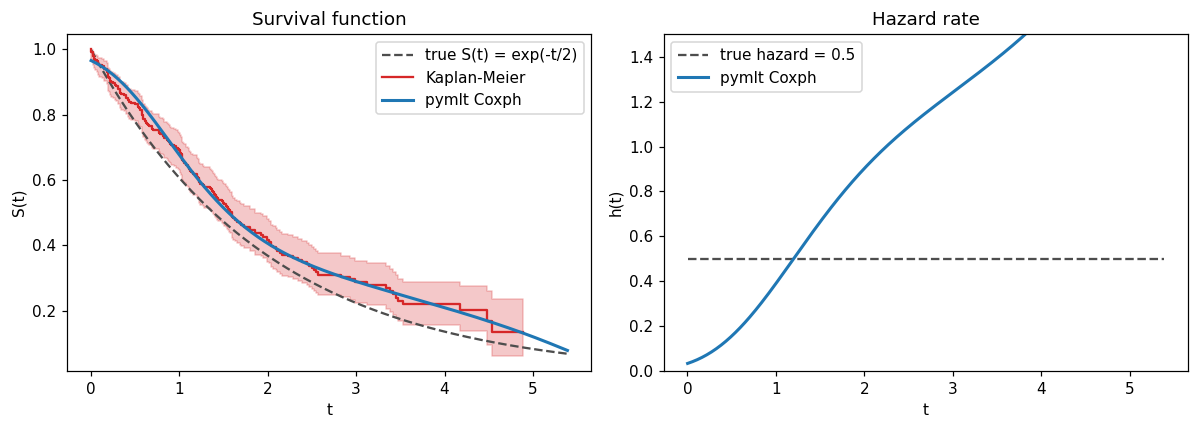

In [5]:
t_grid = np.linspace(support[0] + 1e-3, support[1] - 1e-3, 400)
S_ctm = model.survival(t_grid)
h_ctm = model.hazard(t_grid)
# Truth: Exp(scale=2) has S(t) = exp(-t/2), hazard 0.5.
S_true = np.exp(-t_grid / 2.0)
h_true = np.full_like(t_grid, 0.5)

fig, (ax_s, ax_h) = plt.subplots(1, 2, figsize=(11, 4))

ax_s.plot(t_grid, S_true, "--", color="0.3", label="true S(t) = exp(-t/2)")
kmf.plot_survival_function(ax=ax_s, color="C3", ci_show=True)
ax_s.plot(t_grid, S_ctm, label="pymlt Coxph", lw=2, color="C0")
ax_s.set_xlabel("t")
ax_s.set_ylabel("S(t)")
ax_s.set_title("Survival function")
ax_s.legend()

ax_h.plot(t_grid, h_true, "--", color="0.3", label="true hazard = 0.5")
ax_h.plot(t_grid, h_ctm, label="pymlt Coxph", lw=2, color="C0")
ax_h.set_xlabel("t")
ax_h.set_ylabel("h(t)")
ax_h.set_title("Hazard rate")
ax_h.set_ylim(0, 1.5)
ax_h.legend()
fig.tight_layout();

## Takeaways

- The Coxph estimate tracks the Kaplan-Meier survival curve closely, but
  is smooth — it does not have the staircase pattern of KM and returns
  finite values everywhere inside the support.
- Because the fit is smooth, the *hazard rate* is directly available via
  `model.hazard(t)`. KM provides no hazard estimate without further
  kernel smoothing.
- The median survival time recovered by pymlt sits between the truth
  $2\ln 2 \approx 1.386$ and the KM estimate — both are consistent at
  $n=250$ with ~30 % censoring.
- `Coxph` accepts covariates through `fit(cd, X=X)` exactly like
  `MLT`; the hazard ratios appear in the trailing entries of `model.theta_`.